# Are you middle-aged?

Here's a question from Reddit's [Stupid Questions forum](https://www.reddit.com/r/stupidquestions/comments/1sxesux/what_age_is_actually_considered_middle_age/):

> I always thought middle age was in your 40s but since life expectancy is around 75 or so, wouldn't it be about 35?

If life expectancy is 75, you might think the midpoint is half that, which is 37.5.
But if 75 is life expectancy *at birth* and you survive to age 37.5, your life expectancy *at that age* is higher than 75.
So 37.5 is not halfway!

If we really want to find the midpoint -- and it wouldn't be *Probably Overthinking It* if we didn't -- we have to find the age where your expected remaining lifetime equals your current age.

Let's do it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import decorate, set_pyplot_params

set_pyplot_params()

## Data

From the [Human Mortality Database](https://www.mortality.org/Country/Country?cntr=USA) I downloaded life tables for the United States, combined and broken down for men and women.
The following function reads and cleans a table.

In [2]:
def read_life_table(filename):
    lt = pd.read_fwf(filename, skiprows=2, infer_nrows=200)
    lt['Age'] = lt['Age'].str.replace('+', '', regex=False).astype(int)
    return lt

Here are the first few rows of the combined table (see notes below for details).

In [3]:
blt = read_life_table('../data/bltper_1x1.txt')
blt.head()

,Year,Age,mx,qx,ax,lx,dx,Lx,Tx,ex
0,1933,0,0.06129,0.05861,0.25,100000,5861,95624,6089609,60.90
1,1933,1,0.00946,0.00941,0.50,94139,886,93696,5993985,63.67
2,1933,2,0.00435,0.00434,0.50,93253,405,93050,5900289,63.27
3,1933,3,0.00310,0.00310,0.50,92848,288,92704,5807239,62.55
4,1933,4,0.00239,0.00238,0.50,92560,221,92450,5714535,61.74


We'll also read the female and male tables.

In [4]:
flt = read_life_table('../data/fltper_1x1.txt')

In [5]:
mlt = read_life_table('../data/mltper_1x1.txt')

The tables include data from 1933 to 2024, so we'll select the most recent data.

In [6]:
year = blt['Year'].unique()[-1]
table = blt.query('Year == @year').set_index('Age')

The column we'll use is `ex`, which is life expectancy as a function of age.

In [7]:
age = table.index.to_series()
ex = table['ex']

Life expectancy at birth is 79 years, so the naive midpoint is 39.5.

In [8]:
ex[0], ex[0] / 2

(79.08, 39.54)

But at age 40, expected remaining lifetime is 41.1, so 39.5 is not the midpoint.

In [9]:
ex[39], ex[40]

(42.04, 41.12)

This plot shows life expectancy at each age, compared to age.

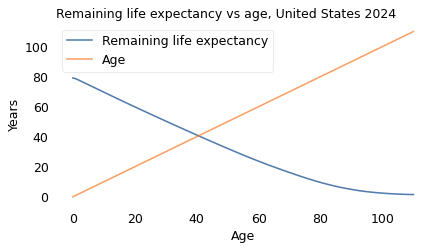

In [10]:
ex.plot(label='Remaining life expectancy')
age.plot(label='Age')
decorate(ylabel='Years', title='Remaining life expectancy vs age, United States 2024')
plt.savefig('midlife.png', dpi=150)

"Middle age" is where the lines cross, which we can compute by linear interpolation.

In [11]:
from scipy.interpolate import interp1d

inverse = interp1d(ex - age, age)
inverse(0)

array(40.58638743)

So the overall midpoint is 40.6 years.
But as you might expect, it's different for men and women.
Let's put the analysis we did in a function.

In [12]:
def get_midpoint(filename):
    lt = read_life_table(filename)
    year = lt['Year'].unique()[-1]
    table = lt.query('Year == @year').set_index('Age')

    age = pd.Series(table.index)
    ex = table['ex']

    inverse = interp1d(ex - age, age)
    return inverse(0)

And run it for men.

In [13]:
get_midpoint('../data/mltper_1x1.txt')

array(39.57142857)

And women.

In [14]:
get_midpoint('../data/fltper_1x1.txt')

array(41.56185567)

Men hit middle age at 39.6, women at 41.6.

## The Gender Gap and Age

Finally, let's see how the gender gap in life expectancy changes as a function of age.

In [15]:
ex_male = mlt.query('Year == @year').set_index('Age')['ex']
ex_female = flt.query('Year == @year').set_index('Age')['ex']
gap = ex_female - ex_male

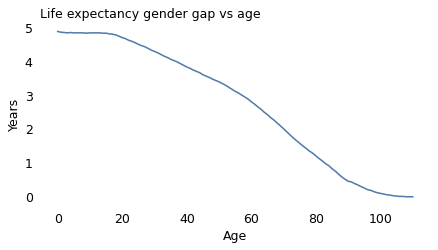

In [16]:
gap.plot(label='')
decorate(ylabel='Years',
         title='Life expectancy gender gap vs age')

At birth the life expectancy gap is close to five years.
At age 100, it is close to zero.

But just looking at the gap might be misleading.
For a more complete picture let's also look at the ratio.

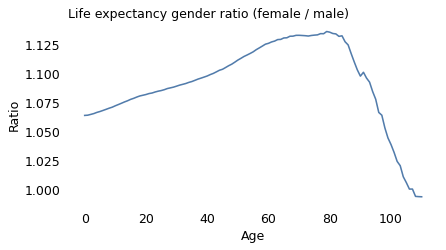

In [17]:
ratio = ex_female / ex_male
ratio.plot(label='')

decorate(ylabel='Ratio',
         title='Life expectancy gender ratio (female / male)')

The life expectancy ratio tells a more complicated story.

* At birth, the ratio is 1.06, which means female babies live 6% longer, on average.

* Around age 80, the ratio peaks at nearly 1.14 -- so between female and male octogenarians, we expect the women to live 14% longer.

* At advanced ages, the ratio declines steeply and actually crosses over after age 100 -- although the crossover is minimal and might not be statistically valid.

To interpret these results, we can think about the causes of death that contribute to age-specific death rates at different stages of life.

* In young adulthood, the causes of death that contribute most to gender gaps include road traffic, homicide, accidental injury, drug disorders.

* In advanced adulthood, they include cancer, cardiovascular disease, respiratory disease, liver disease, diabetes, and suicide.

The causes that affect younger people have large gender gaps, but relatively low death rates.
As people get older, these low-rate causes contribute less to age-specific death rates, and the higher-rate causes contribute more.

I think that's a plausible explanation for the increasing ratio from age 0 to 80.
For the decline that follows, I can only speculate that there is a selection effect: people who get to these advanced ages are likely to have better-than-average lifestyle histories (less smoking and drinking, better diet, more exercise) -- and among people with better lifestyles, the gender gap is small.

### Notes

Data credit: HMD. Human Mortality Database. Max Planck Institute for Demographic Research (Germany), University of California, Berkeley (USA), and French Institute for Demographic Studies (France). Available at [www.mortality.org].

Here are the columns of the 1×1 Period Life Tables:

* **Year**: Calendar year to which the period life table refers.

* **Age**: Exact age (x), in years, at the beginning of the interval ([x, x+1)).

* **mx**: Central death rate at age (x):

$$m_x = \frac{\text{deaths in age interval}}{\text{person-years lived in interval}}$$

* **qx**: Probability of dying between ages (x) and (x+1):

$$q_x = P(\text{death in } [x, x+1) \mid \text{alive at } x)$$

* **ax**: Average fraction of the interval lived by those who die in ([x, x+1)). Typically around 0.5 for most ages, lower for infants (reflecting higher early mortality within the year).

* **lx**: Number of survivors at exact age (x), out of a radix (usually 100,000 births).

* **dx**: Number of deaths between ages (x) and (x+1):

$$d_x = l_x \cdot q_x$$

* **Lx**: Person-years lived between ages (x) and (x+1), approximately

$$L_x \approx l_{x+1} + a_x \cdot d_x$$
  

* **Tx**: Total person-years remaining above age (x):

$$T_x = \sum_{y \ge x} L_y$$

* **ex**: Life expectancy at age (x):

$$e_x = \frac{T_x}{l_x}$$